In [1]:
from pathlib import Path

# === PARAMÈTRES ===
root = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_crossings")
output_file = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_crossings/LiDAR_p2p.txt")

# === RECHERCHE DES DOSSIERS cor_outputs ===
cor_dirs = sorted(p for p in root.rglob("cor_outputs") if p.is_dir())

# === RECHERCHE DES FICHIERS À MERGER ===
files_to_merge = []
for d in cor_dirs:
    files_to_merge.extend(sorted(d.glob("LiDAR_p2p_chunk*")))

files_to_merge = [f for f in files_to_merge if f.is_file()]

print(f"{len(files_to_merge)} fichiers trouvés.")

# === MERGE ===
output_file.parent.mkdir(parents=True, exist_ok=True)

with output_file.open("w", encoding="utf-8") as fout:
    for f in files_to_merge:
        with f.open("r", encoding="utf-8", errors="replace") as fin:
            content = fin.read()
            fout.write(content)
            if not content.endswith("\n"):
                fout.write("\n")

print(f"Merge terminé : {output_file}")

86 fichiers trouvés.
Merge terminé : /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_crossings/LiDAR_p2p.txt


In [ ]:
import numpy as np

f1 = "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch/LiDAR_p2p.txt"
f2 = "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch_crossings/LiDAR_p2p.txt"
out = "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_3_306295_306640/COMBINED/in/LiDAR_p2p.txt"

a = np.loadtxt(f1)
b = np.loadtxt(f2)

print(f"File 1: {len(a)} lines")
print(f"File 2: {len(b)} lines")

merged = np.vstack([a, b])
merged = merged[np.argsort(merged[:, 0])]

print(f"Merged: {len(merged)} lines")

np.savetxt(out, merged, fmt="%.10f")

FileNotFoundError: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/limatch/LiDAR_p2p_1.txt not found.

### stats success rate + nombre de chunks

In [4]:
from pathlib import Path
import pandas as pd

BASE_PATH = "/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch"
KEYWORD   = "LiDAR_p2p"
MIN_SIZE  = 1

def find_output_file(chunk_dir, keyword, min_size):
    cor_dir = chunk_dir / "cor_outputs"
    if not cor_dir.exists():
        return False, "pas de dossier cor_outputs"
    txt_files = list(cor_dir.glob("*.txt"))
    if not txt_files:
        return False, "aucun fichier .txt"
    if keyword:
        txt_files = [f for f in txt_files if keyword in f.name]
        if not txt_files:
            return False, f"aucun fichier contenant '{keyword}'"
    for f in txt_files:
        if f.stat().st_size >= min_size:
            return True, f.name
    return False, f"fichier(s) vide(s) (< {min_size} octets)"

records = []
for sensor_dir in sorted(Path(BASE_PATH).iterdir()):
    if not sensor_dir.is_dir():
        continue
    for chunk_dir in sorted(d for d in sensor_dir.iterdir() if d.is_dir()):
        success, detail = find_output_file(chunk_dir, KEYWORD, MIN_SIZE)
        records.append({"sensor": sensor_dir.name, "chunk": chunk_dir.name,
                        "success": success, "detail": detail})

df = pd.DataFrame(records)
print(f"Chunks trouvés : {len(df)}")

Chunks trouvés : 436


In [5]:
total     = len(df)
n_success = df["success"].sum()
print(f"Total chunks   : {total}")
print(f"Réussis        : {n_success}")
print(f"Échoués        : {total - n_success}")
print(f"Success rate   : {n_success/total*100:.1f}%")

Total chunks   : 436
Réussis        : 337
Échoués        : 99
Success rate   : 77.3%


In [6]:
df["status"] = df["success"].map({True: "✅", False: "❌"})
pd.set_option("display.max_rows", None)
df[["sensor", "chunk", "status", "detail"]]

,sensor,chunk,status,detail
0,merged_1000_VUX_PUCK,chunk_1000__chunk_1001,✅,LiDAR_p2p_rsc_chunk_1000_chunk_1001.txt
1,merged_1000_VUX_PUCK,chunk_1001__chunk_1002,❌,aucun fichier .txt
2,merged_1000_VUX_PUCK,chunk_1002__chunk_1003,❌,aucun fichier .txt
3,merged_1000_VUX_PUCK,chunk_1003__chunk_1004,✅,LiDAR_p2p_rsc_chunk_1003_chunk_1004.txt
4,merged_1000_VUX_PUCK,chunk_1004__chunk_1005,❌,aucun fichier .txt
5,merged_1000_VUX_PUCK,chunk_1005__chunk_1006,❌,aucun fichier .txt
6,merged_1000_VUX_PUCK,chunk_1006__chunk_1007,❌,aucun fichier .txt
7,merged_1000_VUX_PUCK,chunk_1007__chunk_1008,❌,aucun fichier .txt
8,merged_1000_VUX_PUCK,chunk_1008__chunk_1009,✅,LiDAR_p2p_rsc_chunk_1008_chunk_1009.txt
9,merged_1000_VUX_PUCK,chunk_1009__chunk_1010,✅,LiDAR_p2p_rsc_chunk_1009_chunk_1010.txt


In [ ]:
from pathlib import Path

roots = [
    #Path("/media/.../limatch"),
    Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/limatch_crossings_v2"),
]
out_file = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage_chunks/chunks_VUX_PUCK/hybrid/p2p_hybrid/LiDAR_p2p_all.txt")

with open(out_file, "w") as fout:

    for root in roots:
        files = sorted(root.rglob("LiDAR_p2p_chunk_*.txt"))
        files = [f for f in files if "_rsc_" not in f.name]
        for f in files:
            content = f.read_text()
            if content.strip():
                fout.write(content)
                if not content.endswith("\n"):
                    fout.write("\n")

print(f"Merged → {out_file}")

30
Merged → /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage_chunks/chunks_VUX_PUCK/hybrid/p2p_hybrid/LiDAR_p2p_all.txt


: 

In [ ]:
import numpy as np

file = "/media/b085164/Elements/PCD_SAM/village/merged/merged_800_HA_LR.txt"

data = np.loadtxt(file, delimiter=",")

n_points = data.shape[0]

t = data[:, 0]   # colonne 0 = GPS time
tmin = t.min()
tmax = t.max()

print("Number of points:", n_points)
print("tmin:", tmin)
print("tmax:", tmax)

Number of points: 210570172
tmin: 467364.851373258
tmax: 467573.346314613


: 

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- paths ---
in_path = Path("/media/b085164/Elements/Gobet_ODyN_v1/v4.2_GNSS_outage_limatch_kneighbor1/LiDAR_p2p.txt")      # <-- change to your file
out_path = in_path.with_name(in_path.stem + "_rotvec.txt")

# --- load (CSV with commas) ---
df = pd.read_csv(
    in_path,
    header=None,
    comment="#",
    skip_blank_lines=True
)

# expected columns:
# t_b, t_a, vec_b_x, vec_b_y, vec_b_z, vec_a_x, vec_a_y, vec_a_z
if df.shape[1] < 8:
    raise ValueError(f"Expected at least 8 columns, got {df.shape[1]}")

df = df.iloc[:, :8].copy()
df.columns = ["t_b","t_a","vec_b_x","vec_b_y","vec_b_z","vec_a_x","vec_a_y","vec_a_z"]

R = np.array([[0, 1, 0],
              [1, 0, 0],
              [0, 0,-1]], dtype=float)

# --- apply R to vec_b and vec_a ---
vb = df[["vec_b_x","vec_b_y","vec_b_z"]].to_numpy(float)
va = df[["vec_a_x","vec_a_y","vec_a_z"]].to_numpy(float)

vb_rot = (R @ vb.T).T
va_rot = (R @ va.T).T

df[["vec_b_x","vec_b_y","vec_b_z"]] = vb_rot
df[["vec_a_x","vec_a_y","vec_a_z"]] = va_rot

# --- save ---
df.to_csv(out_path, index=False, header=False, float_format="%.12f")
print("Wrote:", out_path)

# quick sanity check: show first rows
df.head()

Wrote: /media/b085164/Elements/Gobet_ODyN_v1/v4.2_GNSS_outage_limatch_kneighbor1/LiDAR_p2p_rotvec.txt


,t_b,t_a,vec_b_x,vec_b_y,vec_b_z,vec_a_x,vec_a_y,vec_a_z
0,466562.626260,466560.883635,6.6399,-9.8000,-1.4228,7.303,5.250,-1.850
1,466562.636280,466560.758630,7.0620,-10.0634,-1.2329,7.779,5.941,-1.695
2,466562.641253,466560.888630,6.6870,-9.9051,-1.4968,7.368,5.249,-1.920
3,466562.646229,466561.138493,5.7895,-9.0442,-1.5612,6.270,4.001,-1.942
4,466562.651217,466561.213481,5.4587,-8.7352,-1.6041,5.986,3.667,-1.959


: 

## Get times of each recording 

In [ ]:
from pathlib import Path
import os

def quick_time_bounds(txt_path, delimiter=","):
    """
    Read GPS time from first and last line of a large TXT file.
    Assumes:
        column 0 = gps time
    """

    txt_path = Path(txt_path)

    with open(txt_path, "rb") as f:

        # ---- FIRST LINE ----
        first_line = f.readline().decode().strip()
        t0 = float(first_line.split(delimiter)[0])

        # ---- LAST LINE (seek from end) ----
        f.seek(-1024, os.SEEK_END)   # jump near end
        tail = f.readlines()

        # find last non-empty line
        for line in reversed(tail):
            if line.strip():
                last_line = line.decode().strip()
                break

        t1 = float(last_line.split(delimiter)[0])

    return t0, t1

: 

In [ ]:
merged_dir = Path("/media/b085164/Elements/PCD_SAM/All_pcd/merged")

results = []

for f in sorted(merged_dir.glob("*.txt")):
    try:
        t0, t1 = quick_time_bounds(f)
        results.append((f.name, t0, t1, t1 - t0))
        print(f"{f.name:<40}  [{t0:.3f} → {t1:.3f}]  Δt={t1-t0:.1f}s")
    except Exception as e:
        print(f"{f.name}: FAILED ({e})")

merged_10000_HA_LR.txt                    [467588.721 → 467594.186]  Δt=5.5s
merged_1000_HA_LR.txt                     [466554.821 → 466860.374]  Δt=305.6s
merged_11000_HA_LR.txt                    [467604.016 → 467683.827]  Δt=79.8s
merged_2000_HA_LR.txt                     [466896.472 → 467160.499]  Δt=264.0s
merged_3000_HA_LR.txt                     [467164.153 → 467180.764]  Δt=16.6s
merged_4000_HA_LR.txt                     [467181.482 → 467205.529]  Δt=24.0s
merged_5000_HA_LR.txt                     [467206.034 → 467211.055]  Δt=5.0s
merged_6000_HA_LR.txt                     [467211.507 → 467226.855]  Δt=15.3s
merged_7000_HA_LR.txt                     [467227.556 → 467257.452]  Δt=29.9s
merged_8000_HA_LR.txt                     [467281.138 → 467348.772]  Δt=67.6s
merged_9000_HA_LR.txt                     [467364.851 → 467573.346]  Δt=208.5s


: 

## Quick GNSS outage 

In [ ]:
from pathlib import Path

# =====================================================
# INPUT
# =====================================================

gps_in = Path("/media/b085164/Elements/Gobet_ODyN_v1/v1_base_AB/in/GPS.txt")
gps_out = Path("/media/b085164/Elements/Gobet_ODyN_v1/v6/in/GPS.txt")

# outages = (start_time, duration)
outages = [
    (466930.0, 200.0),
]

delimiter = ","


# =====================================================
# BUILD OUTAGE INTERVALS
# =====================================================

intervals = [(s, s + d) for s, d in outages]

print("Removing GPS data during:")
for a, b in intervals:
    print(f"  [{a:.3f} → {b:.3f}]")


# =====================================================
# FILTER GPS FILE (STREAMING → works for huge files)
# =====================================================

kept = 0
removed = 0

with open(gps_in, "r") as fin, open(gps_out, "w") as fout:

    for line in fin:

        if not line.strip():
            continue

        t = float(line.split(delimiter)[0])

        # check if inside outage
        in_outage = any(a <= t <= b for a, b in intervals)

        if in_outage:
            removed += 1
            continue

        fout.write(line)
        kept += 1


print("\nDone.")
print(f"Kept lines   : {kept}")
print(f"Removed lines: {removed}")
print(f"Output file  : {gps_out}")

Removing GPS data during:
  [466930.000 → 467130.000]

Done.
Kept lines   : 3086
Removed lines: 201
Output file  : /media/b085164/Elements/Gobet_ODyN_v1/v6/in/GPS.txt


: 

## Split big PCD spatially

In [ ]:
# --- Spatial split into 3 parts (E,N geometry) for TWO huge ASCII point clouds ---
# Assumes each file is a delimited text with at least: [t, E, N, Z, ...]
# You can set which columns are E and N below.

from pathlib import Path
import numpy as np
import pandas as pd
import time

# =========================
# USER CONFIG
# =========================
cloud1 = Path("/media/b085164/Elements/PCD_SAM/longue_ligne/output_Patcher/Flights_1000_2000/Patch_from_scan_1000_with_2000.txt")
cloud2 = Path("/media/b085164/Elements/PCD_SAM/longue_ligne/output_Patcher/Flights_1000_2000/Patch_from_scan_2000_with_1000.txt")

out_dir = Path("/media/b085164/Elements/PCD_SAM/longue_ligne/output_Patcher/output_split")
out_dir.mkdir(parents=True, exist_ok=True)

# delimiter:
# - if whitespace separated: sep = r"\s+" and engine="c"
# - if comma separated: sep = "," and engine="c"
sep = ","          # change to "," if CSV
engine = "c"

# column indices (0-based) for Easting and Northing in your TXT
E_COL = 1
N_COL = 2


CHUNKSIZE = 5_000_000          # try bigger if RAM allows
SAMPLE_TARGET = 600_000        # you can reduce; PCA works well with 200k-1M
SAMPLE_PER_CHUNK = 10_000      # reduce if you want faster first pass

out_sep = "," if sep == "," else " "
float_fmt = "%.6f"

def read_chunks_EN(path: Path):
    for df in pd.read_csv(path, sep=sep, engine=engine, header=None,
                          usecols=[E_COL, N_COL], dtype=np.float64,
                          chunksize=CHUNKSIZE, low_memory=False):
        yield df

def estimate_axis_and_thresholds_from_sample(paths):
    rng = np.random.default_rng(0)
    samples = []
    n_total = 0
    t0 = time.time()

    for p in paths:
        for df in read_chunks_EN(p):
            arr = df.to_numpy(copy=False)
            m = arr.shape[0]
            if m == 0:
                continue
            take = min(SAMPLE_PER_CHUNK, m)
            idx = rng.choice(m, size=take, replace=False)
            samples.append(arr[idx])
            n_total += take
            if n_total >= SAMPLE_TARGET:
                break
        if n_total >= SAMPLE_TARGET:
            break

    X = np.vstack(samples)
    mu = X.mean(axis=0)
    Xc = X - mu
    C = (Xc.T @ Xc) / max(1, (Xc.shape[0] - 1))
    evals, evecs = np.linalg.eigh(C)
    u = evecs[:, np.argmax(evals)]
    u /= np.linalg.norm(u)

    proj = X @ u
    # quantiles on sample => 3 roughly equal parts
    t1, t2 = np.quantile(proj, [1/3, 2/3])

    print(f"[FAST PCA] sample={X.shape[0]:,}, u=[{u[0]:.6f},{u[1]:.6f}], t1={t1:.3f}, t2={t2:.3f} (t={time.time()-t0:.1f}s)")
    return u, float(t1), float(t2)

def split_file_into_3(path_in: Path, u, t1, t2, out_paths):
    outs = [open(p, "w", buffering=1024*1024) for p in out_paths]
    try:
        t0 = time.time()
        n_written = [0,0,0]
        n_total = 0

        for df in pd.read_csv(path_in, sep=sep, engine=engine, header=None,
                              dtype=np.float64, chunksize=CHUNKSIZE, low_memory=False):
            arr = df.to_numpy(copy=False)
            if arr.size == 0:
                continue

            EN = arr[:, [E_COL, N_COL]]
            proj = EN @ u

            m0 = proj < t1
            m1 = (proj >= t1) & (proj < t2)
            m2 = proj >= t2

            if m0.any():
                np.savetxt(outs[0], arr[m0], delimiter=out_sep, fmt=float_fmt); n_written[0]+=int(m0.sum())
            if m1.any():
                np.savetxt(outs[1], arr[m1], delimiter=out_sep, fmt=float_fmt); n_written[1]+=int(m1.sum())
            if m2.any():
                np.savetxt(outs[2], arr[m2], delimiter=out_sep, fmt=float_fmt); n_written[2]+=int(m2.sum())

            n_total += arr.shape[0]
            if n_total % (5*CHUNKSIZE) == 0:
                print(f"  {path_in.name}: processed {n_total:,} rows...")

        print(f"[SPLIT] {path_in.name}: {n_written[0]:,}/{n_written[1]:,}/{n_written[2]:,} (t={time.time()-t0:.1f}s)")
    finally:
        for f in outs: f.close()

u, t1, t2 = estimate_axis_and_thresholds_from_sample([cloud1, cloud2])

c1_out = [out_dir/f"{cloud1.stem}__part1.txt", out_dir/f"{cloud1.stem}__part2.txt", out_dir/f"{cloud1.stem}__part3.txt"]
c2_out = [out_dir/f"{cloud2.stem}__part1.txt", out_dir/f"{cloud2.stem}__part2.txt", out_dir/f"{cloud2.stem}__part3.txt"]

print("\n--- Splitting cloud 1 ---")
split_file_into_3(cloud1, u, t1, t2, c1_out)

print("\n--- Splitting cloud 2 ---")
split_file_into_3(cloud2, u, t1, t2, c2_out)

print("\nDone.")

[FAST PCA] sample=600,000, u=[-0.948999,-0.315278], t1=-2780962.986, t2=-2779498.092 (t=89.3s)

--- Splitting cloud 1 ---
  Patch_from_scan_1000_with_2000.txt: processed 25,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 50,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 75,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 100,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 125,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 150,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 175,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 200,000,000 rows...
  Patch_from_scan_1000_with_2000.txt: processed 225,000,000 rows...
[SPLIT] Patch_from_scan_1000_with_2000.txt: 43,375,613/84,282,195/100,012,993 (t=546.2s)

--- Splitting cloud 2 ---
  Patch_from_scan_2000_with_1000.txt: processed 25,000,000 rows...
  Patch_from_scan_2000_with_1000.txt: processed 50,000,000 rows...
  Patch_from_scan_2

: 

In [ ]:
from pathlib import Path

# adapte cet import selon où tu exécutes le notebook
from singleBeamMerging import merge_txt_pairs

base_root = Path("/media/b085164/Elements/PCD_SAM/Georef_v6")
scenarios = ["ref", "outage_only"]

for scenario in scenarios:
    scenario_dir = base_root / scenario
    dir_ha = scenario_dir / "HA"
    dir_lr = scenario_dir / "LR"
    out_dir = scenario_dir / "merged"

    print("\n" + "=" * 70)
    print(f"[MERGING SCENARIO] {scenario}")
    print(f"HA dir   : {dir_ha}")
    print(f"LR dir   : {dir_lr}")
    print(f"OUT dir  : {out_dir}")
    print("=" * 70)

    merge_txt_pairs(
        dir_a=dir_ha,
        dir_b=dir_lr,
        out_dir=out_dir,
        delimiter=",",
        skiprows=0,
        sort_by_time=True,
        out_prefix="merged_",
        out_suffix="_HA_LR",
    )

print("\n[DONE] ref + outage_only merged.")


[MERGING SCENARIO] ref
HA dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/ref/HA
LR dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/ref/LR
OUT dir  : /media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged

 [Merging] files /media/b085164/Elements/PCD_SAM/Georef_v6/ref/HA/250220_094117_VUX-HA1_pcd.txt and /media/b085164/Elements/PCD_SAM/Georef_v6/ref/LR/250220_094117_VUX1-LR_pcd.txt
250220_094117_VUX-HA1_pcd.txt + 250220_094117_VUX1-LR_pcd.txt -> merged_94117_HA_LR.txt (140986168 + 120925420 rows)

--- Summary ---
[Merging] Pairs found: 1 | Merged: 1
[Merging] Output dir: /media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged

[MERGING SCENARIO] outage_only
HA dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/HA
LR dir   : /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/LR
OUT dir  : /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged

 [Merging] files /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/HA/250220_094117_VUX-HA1_pcd.txt and /media/b085164/El

: 

In [ ]:
from pathlib import Path
from tqdm import tqdm

# -------------------------------------------------------------------
# ROOT FOLDER TO SCAN
# -------------------------------------------------------------------
root_folder = Path("/media/b085164/Elements/PCD_SAM/Georef_v6/")

# -------------------------------------------------------------------
# FUNCTION: fast line counting (streaming)
# -------------------------------------------------------------------
def count_lines_fast(file_path, chunk_size=1024*1024*16):
    count = 0
    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            count += chunk.count(b"\n")
    return count

# -------------------------------------------------------------------
# FIND ALL TXT FILES
# -------------------------------------------------------------------
txt_files = sorted(root_folder.rglob("*.txt"))

print(f"Found {len(txt_files)} txt files\n")

results = []

for f in tqdm(txt_files, desc="Counting lines"):
    try:
        n = count_lines_fast(f)
        results.append((str(f), n))
    except Exception as e:
        results.append((str(f), f"ERROR: {e}"))

# -------------------------------------------------------------------
# PRINT RESULTS
# -------------------------------------------------------------------
print("\n================ LINE COUNTS ================\n")

for path, n in results:
    print(f"{n:>15}  |  {path}")


Found 4 txt files



Counting lines: 100%|██████████| 4/4 [16:17<00:00, 244.38s/it]



================ LINE COUNTS ================

Found 4 txt files



Counting lines: 100%|██████████| 4/4 [19:00<00:00, 285.16s/it]


================ LINE COUNTS ================

      261911575  |  /media/b085164/Elements/PCD_SAM/Georef_v6/limatch_chunk2chunk/merged/merged_94117_HA_LR.txt
      261911762  |  /media/b085164/Elements/PCD_SAM/Georef_v6/limatch_scan2scan/merged/merged_94117_HA_LR.txt
      261911555  |  /media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged/merged_94117_HA_LR.txt
      261911588  |  /media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged/merged_94117_HA_LR.txt


: 

In [ ]:
from pathlib import Path

def first_last_valid_line(path):
    path = Path(path)

    # ---- first non-empty line
    with open(path, "r", errors="ignore") as f:
        first = None
        for line in f:
            line = line.strip()
            if line:
                first = line
                break

    # ---- last non-empty line
    with open(path, "rb") as f:
        f.seek(0, 2)
        pos = f.tell() - 1
        last = None
        buffer = b""

        while pos > 0:
            f.seek(pos)
            char = f.read(1)

            if char == b"\n":
                line = buffer[::-1].decode("utf-8", errors="ignore").strip()
                if line:
                    last = line
                    break
                buffer = b""
            else:
                buffer += char

            pos -= 1

        if last is None:
            last = buffer[::-1].decode("utf-8", errors="ignore").strip()

    return first, last


def parse_time(line, delim=",", time_col=0):
    parts = [p.strip() for p in line.split(delim)]
    return float(parts[time_col])


ref_txt = "/media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged/merged_94117_HA_LR.txt"
tgt_txt = "/media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged/merged_94117_HA_LR.txt"

for label, path in [("REF", ref_txt), ("TGT", tgt_txt)]:
    first, last = first_last_valid_line(path)

    t0 = parse_time(first)
    t1 = parse_time(last)

    print("================================")
    print(label)
    print("first line:", first[:120])
    print("last  line:", last[:120])
    print("time range:", t0, "->", t1)
    print()

REF
first line: 466896.4715145370,2546313.0499999998,1158624.5959999999,875.2490000000,-16.2140000000,-11.5380000000,2.3540000000
last  line: 467160.4990706540,2542670.3380000000,1157328.1259999999,906.4630000000,11.0020000000,-12.6730000000,1.9690000000
time range: 466896.471514537 -> 467160.499070654

TGT
first line: 466896.4715145370,2546313.0510000000,1158624.5959999999,875.2490000000,-16.2140000000,-11.5380000000,2.3540000000
last  line: 467160.4990706540,2542670.3369999998,1157328.1270000001,906.4650000000,11.0020000000,-12.6730000000,1.9690000000
time range: 466896.471514537 -> 467160.499070654



: 

In [ ]:
from pathlib import Path

ref_txt = Path("/media/b085164/Elements/PCD_SAM/Georef_v6/ref/merged/merged_94117_HA_LR.txt")
tgt_txt = Path("/media/b085164/Elements/PCD_SAM/Georef_v6/outage_only/merged/merged_94117_HA_LR.txt")

def first_token(line, delim=","):
    return line.split(delim, 1)[0].strip()

def compare_times_streaming(ref_path, tgt_path, delim=",", max_report=10):
    n = 0
    diffs = []

    with open(ref_path, "r", errors="ignore") as f_ref, open(tgt_path, "r", errors="ignore") as f_tgt:
        while True:
            lref = f_ref.readline()
            ltgt = f_tgt.readline()

            if not lref and not ltgt:
                break

            n += 1

            # cas fin de fichier asymétrique
            if not lref:
                diffs.append((n, "REF_EOF", None, first_token(ltgt, delim)))
                break
            if not ltgt:
                diffs.append((n, "TGT_EOF", first_token(lref, delim), None))
                break

            lref = lref.strip()
            ltgt = ltgt.strip()

            if not lref or not ltgt:
                diffs.append((n, "EMPTY_LINE", lref, ltgt))
                if len(diffs) >= max_report:
                    break
                continue

            tref = first_token(lref, delim)
            ttgt = first_token(ltgt, delim)

            if tref != ttgt:
                diffs.append((n, "TIME_MISMATCH", tref, ttgt))
                if len(diffs) >= max_report:
                    break

    return diffs, n

diffs, n_checked = compare_times_streaming(ref_txt, tgt_txt)

print(f"Lines checked: {n_checked}")
if not diffs:
    print("No timestamp mismatch found on aligned line-by-line comparison.")
else:
    print("\nFirst mismatches found:\n")
    for d in diffs:
        print(d)

Lines checked: 62209469

First mismatches found:

(62209460, 'TIME_MISMATCH', '466958.6020512580', '466958.6020506240')
(62209461, 'TIME_MISMATCH', '466958.6020521460', '466958.6020512580')
(62209462, 'TIME_MISMATCH', '466958.6020531140', '466958.6020521460')
(62209463, 'TIME_MISMATCH', '466958.6020541680', '466958.6020531140')
(62209464, 'TIME_MISMATCH', '466958.6020550930', '466958.6020541680')
(62209465, 'TIME_MISMATCH', '466958.6020561050', '466958.6020550930')
(62209466, 'TIME_MISMATCH', '466958.6020569930', '466958.6020561050')
(62209467, 'TIME_MISMATCH', '466958.6020579610', '466958.6020569930')
(62209468, 'TIME_MISMATCH', '466958.6020590140', '466958.6020579610')
(62209469, 'TIME_MISMATCH', '466958.6020599430', '466958.6020590140')


: 

## Comparaing SBET trajectories (Julien & RD) CALIB

In [ ]:
# ============================================================
# Compare two SBET files on common time interval
# - interactive Plotly figures
# - position and attitude metrics
# - handles different durations (overlap only)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R, Slerp
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
sbet_ref = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/reference.out")
sbet_cmp = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out")

# If your SBET time is GPS seconds-of-week and one file has small edge mismatch,
# you can optionally trim a tiny safety margin:
time_margin_s = 0.0

# ------------------------------------------------------------
# Standard Applanix SBET dtype (17 float64 values per record)
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",        np.float64),
    ("lat",         np.float64),   # radians
    ("lon",         np.float64),   # radians
    ("alt",         np.float64),   # meters
    ("vx",          np.float64),
    ("vy",          np.float64),
    ("vz",          np.float64),
    ("roll",        np.float64),   # radians
    ("pitch",       np.float64),   # radians
    ("heading",     np.float64),   # radians
    ("wander",      np.float64),
    ("ax",          np.float64),
    ("ay",          np.float64),
    ("az",          np.float64),
    ("wx",          np.float64),
    ("wy",          np.float64),
    ("wz",          np.float64),
])

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_sbet(path: Path) -> pd.DataFrame:
    arr = np.fromfile(path, dtype=SBET_DTYPE)
    if arr.size == 0:
        raise ValueError(f"Empty SBET or unreadable file: {path}")
    df = pd.DataFrame(arr)
    return df

def wrap_angle_rad(a):
    """Wrap angle to [-pi, pi]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

def rad2deg(a):
    return np.rad2deg(a)

def geodetic_to_local_enu(lat, lon, h, lat0, lon0, h0):
    """
    Approximate local ENU from geodetic coordinates.
    Good enough for trajectory comparison over local extents.
    lat/lon in radians, h in meters.
    """
    # WGS84
    a = 6378137.0
    f = 1 / 298.257223563
    e2 = f * (2 - f)

    def geodetic_to_ecef(lat, lon, h):
        sin_lat = np.sin(lat)
        cos_lat = np.cos(lat)
        sin_lon = np.sin(lon)
        cos_lon = np.cos(lon)
        N = a / np.sqrt(1 - e2 * sin_lat**2)
        X = (N + h) * cos_lat * cos_lon
        Y = (N + h) * cos_lat * sin_lon
        Z = (N * (1 - e2) + h) * sin_lat
        return X, Y, Z

    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_lon0 = np.sin(lon0)
    cos_lon0 = np.cos(lon0)

    t = np.array([
        [-sin_lon0,              cos_lon0,             0],
        [-sin_lat0*cos_lon0, -sin_lat0*sin_lon0, cos_lat0],
        [ cos_lat0*cos_lon0,  cos_lat0*sin_lon0, sin_lat0],
    ])

    xyz = np.vstack([dX, dY, dZ])
    enu = t @ xyz
    return enu[0], enu[1], enu[2]

def make_rotation_from_rph(roll, pitch, heading):
    """
    Build scipy Rotation from roll/pitch/heading.
    Convention chosen here: intrinsic XYZ on body angles, using
    roll, pitch, heading as x, y, z Euler sequence.
    If your convention is different, adapt here.
    """
    return R.from_euler("xyz", np.column_stack([roll, pitch, heading]), degrees=False)

def summary_stats(x):
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "rms": float(np.sqrt(np.mean(x**2))),
        "max_abs": float(np.max(np.abs(x))),
        "p95_abs": float(np.percentile(np.abs(x), 95)),
    }

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
df_ref = load_sbet(sbet_ref)
df_cmp = load_sbet(sbet_cmp)

print("Loaded:")
print(f"  RD: {sbet_ref} -> {len(df_ref):,} records")
print(f"  Julien: {sbet_cmp} -> {len(df_cmp):,} records")

print("\nTime spans:")
print(f"  RD: [{df_ref.time.min():.4f}, {df_ref.time.max():.4f}]")
print(f"  Julien: [{df_cmp.time.min():.4f}, {df_cmp.time.max():.4f}]")

# ------------------------------------------------------------
# Restrict to common overlap
# ------------------------------------------------------------
t0 = max(df_ref.time.min(), df_cmp.time.min()) + time_margin_s
t1 = min(df_ref.time.max(), df_cmp.time.max()) - time_margin_s

if t1 <= t0:
    raise ValueError(
        f"No common time overlap.\n"
        f"RD: [{df_ref.time.min():.4f}, {df_ref.time.max():.4f}]\n"
        f"Julien: [{df_cmp.time.min():.4f}, {df_cmp.time.max():.4f}]"
    )

df_ref_ov = df_ref[(df_ref.time >= t0) & (df_ref.time <= t1)].copy()
df_cmp_ov = df_cmp[(df_cmp.time >= t0) & (df_cmp.time <= t1)].copy()

print("\nCommon overlap:")
print(f"  [{t0:.4f}, {t1:.4f}]")
print(f"  RD overlap samples: {len(df_ref_ov):,}")
print(f"  Julien overlap samples: {len(df_cmp_ov):,}")

t = df_ref_ov.time.to_numpy()

# ------------------------------------------------------------
# Interpolate CMP position onto REF times
# ------------------------------------------------------------
interp_lat = interp1d(df_cmp_ov.time, df_cmp_ov.lat, kind="linear", bounds_error=True)
interp_lon = interp1d(df_cmp_ov.time, df_cmp_ov.lon, kind="linear", bounds_error=True)
interp_alt = interp1d(df_cmp_ov.time, df_cmp_ov.alt, kind="linear", bounds_error=True)

lat_ref = df_ref_ov.lat.to_numpy()
lon_ref = df_ref_ov.lon.to_numpy()
alt_ref = df_ref_ov.alt.to_numpy()

lat_cmp_i = interp_lat(t)
lon_cmp_i = interp_lon(t)
alt_cmp_i = interp_alt(t)

# ------------------------------------------------------------
# Local ENU trajectories (same origin = first REF overlap sample)
# ------------------------------------------------------------
lat0 = lat_ref[0]
lon0 = lon_ref[0]
h0 = alt_ref[0]

E_ref, N_ref, U_ref = geodetic_to_local_enu(lat_ref, lon_ref, alt_ref, lat0, lon0, h0)
E_cmp, N_cmp, U_cmp = geodetic_to_local_enu(lat_cmp_i, lon_cmp_i, alt_cmp_i, lat0, lon0, h0)

dE = E_cmp - E_ref
dN = N_cmp - N_ref
dU = U_cmp - U_ref
dh = np.sqrt(dE**2 + dN**2)
d3 = np.sqrt(dE**2 + dN**2 + dU**2)

# ------------------------------------------------------------
# Interpolate CMP attitude onto REF times using SLERP
# ------------------------------------------------------------
rot_ref = make_rotation_from_rph(
    df_ref_ov.roll.to_numpy(),
    df_ref_ov.pitch.to_numpy(),
    df_ref_ov.heading.to_numpy(),
)

rot_cmp = make_rotation_from_rph(
    df_cmp_ov.roll.to_numpy(),
    df_cmp_ov.pitch.to_numpy(),
    df_cmp_ov.heading.to_numpy(),
)

slerp = Slerp(df_cmp_ov.time.to_numpy(), rot_cmp)
rot_cmp_i = slerp(t)

rot_rel = rot_ref.inv() * rot_cmp_i
rotvec_rel = rot_rel.as_rotvec()
angle_total_deg = np.rad2deg(np.linalg.norm(rotvec_rel, axis=1))

roll_ref = df_ref_ov.roll.to_numpy()
pitch_ref = df_ref_ov.pitch.to_numpy()
heading_ref = df_ref_ov.heading.to_numpy()

eul_cmp_i = rot_cmp_i.as_euler("xyz", degrees=False)
roll_cmp_i = eul_cmp_i[:, 0]
pitch_cmp_i = eul_cmp_i[:, 1]
heading_cmp_i = eul_cmp_i[:, 2]

droll_deg = rad2deg(wrap_angle_rad(roll_cmp_i - roll_ref))
dpitch_deg = rad2deg(wrap_angle_rad(pitch_cmp_i - pitch_ref))
dheading_deg = rad2deg(wrap_angle_rad(heading_cmp_i - heading_ref))

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metrics = {
    "horizontal_m": summary_stats(dh),
    "vertical_m": summary_stats(dU),
    "position_3d_m": summary_stats(d3),
    "roll_deg": summary_stats(droll_deg),
    "pitch_deg": summary_stats(dpitch_deg),
    "heading_deg": summary_stats(dheading_deg),
    "attitude_total_deg": summary_stats(angle_total_deg),
}

metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

# ------------------------------------------------------------
# Plot 1: simple position differences
# ------------------------------------------------------------
fig_pos = make_subplots(
    rows=5, cols=1, shared_xaxes=True, vertical_spacing=0.04,
    subplot_titles=("dE [m]", "dN [m]", "dU [m]", "Horizontal [m]", "3D [m]")
)

fig_pos.add_trace(go.Scattergl(x=t, y=dE, name="dE"), row=1, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=dN, name="dN"), row=2, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=dU, name="dU"), row=3, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=dh, name="Horizontal"), row=4, col=1)
fig_pos.add_trace(go.Scattergl(x=t, y=d3, name="3D"), row=5, col=1)

fig_pos.update_layout(
    title="SBET comparison - Position differences",
    height=1100,
)
fig_pos.update_xaxes(title_text="Time [s]", row=5, col=1)
fig_pos.show()

# ------------------------------------------------------------
# Plot 2: simple attitude differences
# ------------------------------------------------------------
fig_att = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.04,
    subplot_titles=("dRoll [deg]", "dPitch [deg]", "dHeading [deg]", "Total relative angle [deg]")
)

fig_att.add_trace(go.Scattergl(x=t, y=droll_deg, name="dRoll"), row=1, col=1)
fig_att.add_trace(go.Scattergl(x=t, y=dpitch_deg, name="dPitch"), row=2, col=1)
fig_att.add_trace(go.Scattergl(x=t, y=dheading_deg, name="dHeading"), row=3, col=1)
fig_att.add_trace(go.Scattergl(x=t, y=angle_total_deg, name="Total attitude angle"), row=4, col=1)

fig_att.update_layout(
    title="SBET comparison - Attitude differences",
    height=950,
)
fig_att.update_xaxes(title_text="Time [s]", row=4, col=1)
fig_att.show()

print("\nQuick summary:")
print(f"  Horizontal RMS:   {metrics['horizontal_m']['rms']:.4f} m")
print(f"  Vertical RMS:     {metrics['vertical_m']['rms']:.4f} m")
print(f"  3D RMS:           {metrics['position_3d_m']['rms']:.4f} m")
print(f"  Roll RMS:         {metrics['roll_deg']['rms']:.6f} deg")
print(f"  Pitch RMS:        {metrics['pitch_deg']['rms']:.6f} deg")
print(f"  Heading RMS:      {metrics['heading_deg']['rms']:.6f} deg")
print(f"  Total angle RMS:  {metrics['attitude_total_deg']['rms']:.6f} deg")

Loaded:
  RD: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/reference.out -> 556,368 records
  Julien: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/out/ODyN_GNSS_INS.out -> 39,900 records

Time spans:
  RD: [304508.0000, 307276.0000]
  Julien: [304790.0043, 306784.9543]

Common overlap:
  [304790.0043, 306784.9543]
  RD overlap samples: 400,985
  Julien overlap samples: 39,900


,mean,median,rms,max_abs,p95_abs
horizontal_m,0.014672,0.007558,0.031136,0.200687,0.070174
vertical_m,0.005353,0.000105,0.030536,0.216460,0.038342
position_3d_m,0.020050,0.009692,0.043611,0.294907,0.081036
roll_deg,0.000002,-0.000057,0.011022,0.204479,0.022303
pitch_deg,0.000690,0.000864,0.013718,0.144439,0.028859
heading_deg,-0.001736,-0.002872,0.022901,0.145510,0.048121
attitude_total_deg,0.023619,0.019797,0.028866,0.229297,0.055177


### simple merge .txt

In [ ]:
from pathlib import Path
import numpy as np

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
file1 = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p_1.txt")
file2 = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p_2.txt")
out_file = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p.txt")

delimiter = ","
skiprows = 0
sort_by_first_column = True

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
a = np.loadtxt(file1, delimiter=delimiter, skiprows=skiprows)
b = np.loadtxt(file2, delimiter=delimiter, skiprows=skiprows)

if a.ndim == 1:
    a = a.reshape(1, -1)
if b.ndim == 1:
    b = b.reshape(1, -1)

if a.shape[1] != b.shape[1]:
    raise ValueError(
        f"Column mismatch: {file1.name} has {a.shape[1]} cols, "
        f"{file2.name} has {b.shape[1]} cols."
    )

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------
merged = np.vstack([a, b])

if sort_by_first_column:
    merged = merged[np.argsort(merged[:, 0])]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
out_file.parent.mkdir(parents=True, exist_ok=True)
np.savetxt(out_file, merged, delimiter=delimiter, fmt="%.10f")

print(f"Merged file saved to: {out_file}")
print(f"Rows: {len(a)} + {len(b)} = {len(merged)}")

Merged file saved to: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/p2p/LiDAR_p2p.txt
Rows: 1481 + 5551 = 7032


: 

## GPS quality (coupure et plot sigmas)

/tmp/ipykernel_313212/4293906530.py:72: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(g.t_start, g.t_end,


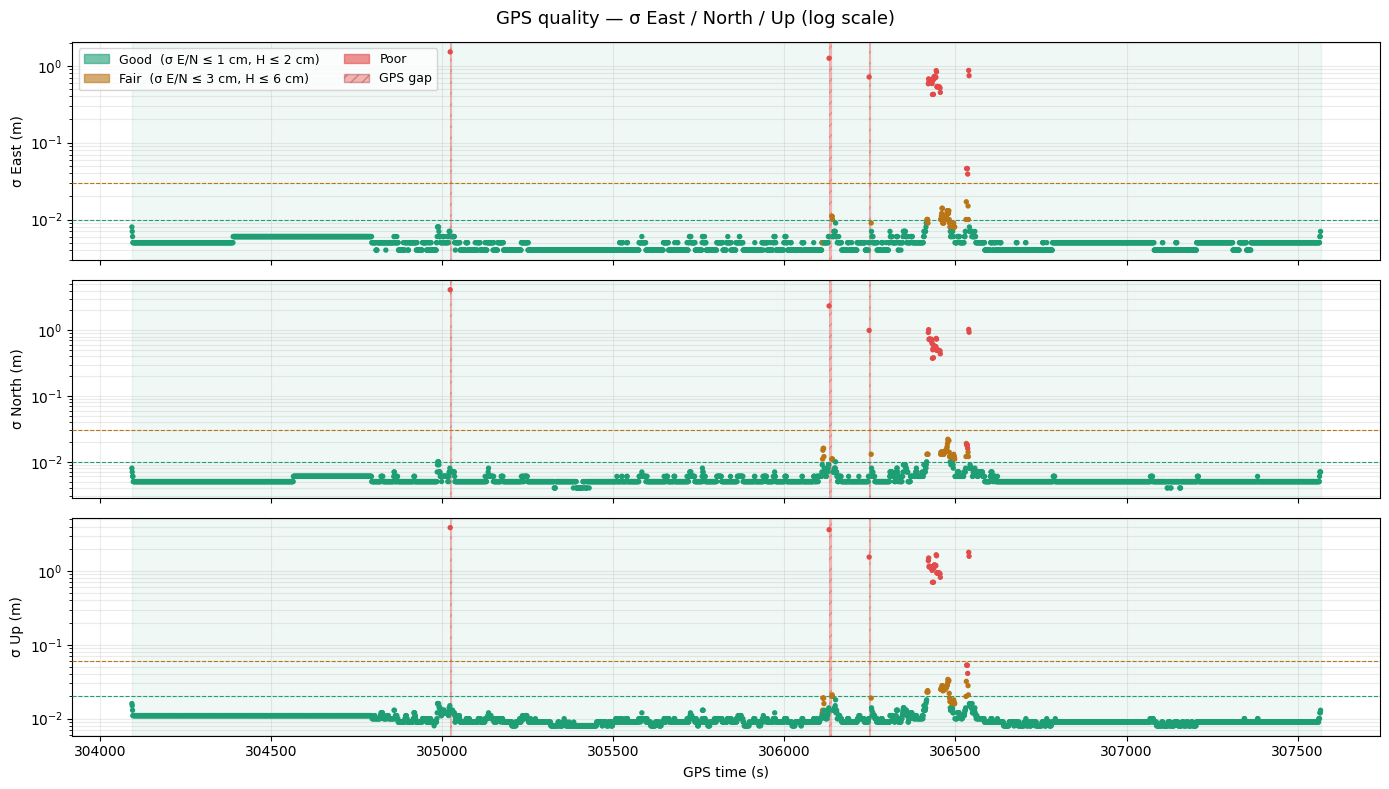


3 gap(s) detected — nominal rate: 1.0 s
  #1  305024.0 → 305030.0   Δt = 6.0 s  (00h00m06s)
  #2  306131.0 → 306139.0   Δt = 8.0 s  (00h00m08s)
  #3  306248.0 → 306254.0   Δt = 6.0 s  (00h00m06s)


: 

## Visualize p2p NED

353140 points chargés (1 sur 100000)


KeyboardInterrupt: 

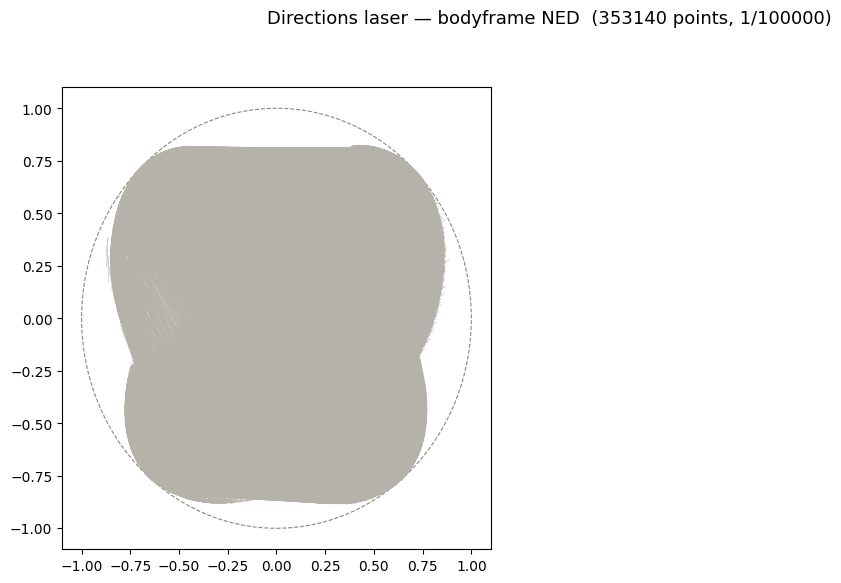

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Chargement ────────────────────────────────────────────────────────────
df = pd.read_csv("/media/b085164/Elements/Gobet_ODyN_v1/v6/LiDAR_p2p.txt", header=None,
                 names=["t1", "t2",
                        "N1", "E1", "D1",
                        "N2", "E2", "D2"])
STEP = 100000
print(f"{len(df)} points chargés (1 sur {STEP})")

# ── Normalisation ─────────────────────────────────────────────────────────
def normalize(N, E, D):
    norm = np.sqrt(N**2 + E**2 + D**2)
    return N/norm, E/norm, D/norm

n1, e1, d1 = normalize(df.N1, df.E1, df.D1)
n2, e2, d2 = normalize(df.N2, df.E2, df.D2)
# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 6))
fig.suptitle(f"Directions laser — bodyframe NED  ({len(df)} points, 1/{STEP})",
             fontsize=13, y=1.01)
gs = gridspec.GridSpec(1, 2, wspace=0.35)

def setup_ax(ax, xlabel, ylabel, title):
    ax.set_aspect("equal")
    ax.axhline(0, color="#B4B2A9", lw=0.5)
    ax.axvline(0, color="#B4B2A9", lw=0.5)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])

# ── Planimétrie (plan N-E)  N↑  E→ ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.add_patch(plt.Circle((0,0), 1, fill=False, lw=0.8,
                         color="#888780", linestyle="--"))
for i in range(len(df)):
    ax1.plot([e1.iloc[i], e2.iloc[i]], [n1.iloc[i], n2.iloc[i]],
             color="#B4B2A9", lw=0.3, zorder=2)
ax1.scatter(e1, n1, s=6, color="#534AB7", alpha=0.5, label="Laser 1", zorder=3)
ax1.scatter(e2, n2, s=6, color="#D85A30", alpha=0.5, label="Laser 2", zorder=3)
for txt, xy in zip(["N","S","E","W"],
                   [(0,1.18),(0,-1.18),(1.18,0),(-1.18,0)]):
    ax1.text(*xy, txt, ha="center", va="center", fontsize=9, color="#5F5E5A")
setup_ax(ax1, "E →", "N ↑", "Planimétrie (plan N-E)")
ax1.legend(fontsize=9, loc="lower right")

# ── Altimétrie (plan N-D)  N→  haut↑ ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.add_patch(plt.Circle((0,0), 1, fill=False, lw=0.8,
                         color="#888780", linestyle="--"))
for i in range(len(df)):
    ax2.plot([n1.iloc[i], n2.iloc[i]], [-d1.iloc[i], -d2.iloc[i]],
             color="#B4B2A9", lw=0.3, zorder=2)
ax2.scatter(n1, -d1, s=6, color="#534AB7", alpha=0.5, label="Laser 1", zorder=3)
ax2.scatter(n2, -d2, s=6, color="#D85A30", alpha=0.5, label="Laser 2", zorder=3)
for txt, xy in zip(["N","S","haut","bas"],
                   [(1.18,0),(-1.18,0),(0,1.18),(0,-1.18)]):
    ax2.text(*xy, txt, ha="center", va="center", fontsize=9, color="#5F5E5A")
setup_ax(ax2, "N →", "−D (haut ↑)", "Altimétrie (plan N-D)")
ax2.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("laser_directions.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_865485/173777576.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


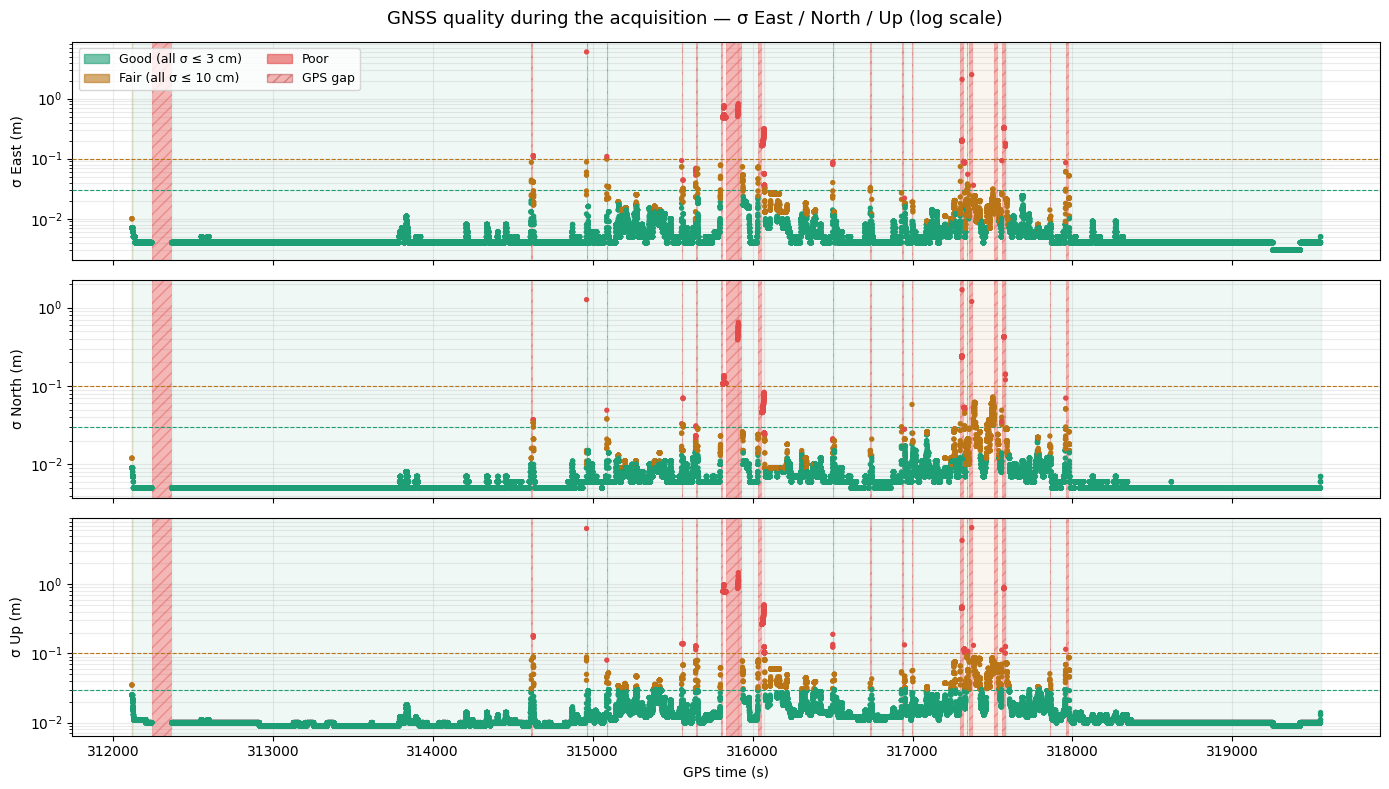


32 gap(s) detected — nominal rate: 0.1 s
  #1  312119.0 → 312119.2   Δt = 0.2 s  (00h00m00s)
  #2  312119.2 → 312119.4   Δt = 0.2 s  (00h00m00s)
  #3  312119.4 → 312119.6   Δt = 0.2 s  (00h00m00s)
  #4  312243.2 → 312368.3   Δt = 125.1 s  (00h02m05s)
  #5  314616.4 → 314628.5   Δt = 12.1 s  (00h00m12s)
  #6  314961.7 → 314971.7   Δt = 10.0 s  (00h00m10s)
  #7  315088.4 → 315097.9   Δt = 9.5 s  (00h00m09s)
  #8  315556.5 → 315564.9   Δt = 8.4 s  (00h00m08s)
  #9  315645.2 → 315656.5   Δt = 11.3 s  (00h00m11s)
  #10  315799.5 → 315814.3   Δt = 14.8 s  (00h00m14s)
  #11  315832.0 → 315906.5   Δt = 74.5 s  (00h01m14s)
  #12  315907.3 → 315908.5   Δt = 1.2 s  (00h00m01s)
  #13  315909.7 → 315910.6   Δt = 0.9 s  (00h00m00s)
  #14  315911.5 → 315936.5   Δt = 25.0 s  (00h00m25s)
  #15  316035.4 → 316056.9   Δt = 21.5 s  (00h00m21s)
  #16  316071.8 → 316072.3   Δt = 0.5 s  (00h00m00s)
  #17  316501.4 → 316510.9   Δt = 9.5 s  (00h00m09s)
  #18  316736.4 → 316744.8   Δt = 8.4 s  (00h00m08s)
  #1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Chargement ────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/media/b085164/LaCie/2026_RD/ECCR/ODyN/GPS.txt",
    header=None,
    names=["time", "lat", "lon", "alt", "sig_E", "sig_N", "sig_H"]
)
df = df.sort_values("time").reset_index(drop=True)

# ── Quality thresholds (same for E / N / H) ──────────────────────────────
THR_GOOD = 0.03   # 3 cm
THR_WARN = 0.10   # 10 cm

# ── Quality flag per epoch ────────────────────────────────────────────────
def quality(row):
    vals = [row.sig_E, row.sig_N, row.sig_H]
    if all(v <= THR_GOOD for v in vals):
        return "good"
    elif all(v <= THR_WARN for v in vals):
        return "warn"
    return "bad"

df["quality"] = df.apply(quality, axis=1)

# ── Continuous segments + gaps ────────────────────────────────────────────
dt = df["time"].diff()
nominal_dt = dt.mode()[0]
threshold = dt.mode()[0] * 1.5
df["seg_id"] = (dt > threshold).cumsum()

segments, gaps = [], []
for sid, grp in df.groupby("seg_id"):
    dominant = grp["quality"].mode()[0]
    segments.append({
        "seg": sid + 1,
        "t_start": grp["time"].iloc[0],
        "t_end": grp["time"].iloc[-1],
        "duration": grp["time"].iloc[-1] - grp["time"].iloc[0],
        "n_epochs": len(grp),
        "quality": dominant,
        "sig_E_mean": grp["sig_E"].mean(),
        "sig_N_mean": grp["sig_N"].mean(),
        "sig_H_mean": grp["sig_H"].mean(),
    })

gap_idx = df.index[dt > threshold]
for i in gap_idx:
    gaps.append({
        "t_start": df["time"].iloc[i - 1],
        "t_end": df["time"].iloc[i],
        "dur": df["time"].iloc[i] - df["time"].iloc[i - 1],
    })

seg_df = pd.DataFrame(segments)
gap_df = pd.DataFrame(gaps) if gaps else pd.DataFrame(columns=["t_start", "t_end", "dur"])

# ── Plot ──────────────────────────────────────────────────────────────────
color_map = {"good": "#1D9E75", "warn": "#BA7517", "bad": "#E24B4A"}
cols = ["sig_E", "sig_N", "sig_H"]
labels = ["σ East (m)", "σ North (m)", "σ Up (m)"]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("GNSS quality during the acquisition — σ East / North / Up (log scale)", fontsize=13)

for ax, col, label in zip(axes, cols, labels):
    for _, s in seg_df.iterrows():
        ax.axvspan(
            s.t_start, s.t_end,
            alpha=0.07, color=color_map[s.quality], zorder=1
        )

    for _, g in gap_df.iterrows():
        ax.axvspan(
            g.t_start, g.t_end,
            alpha=0.40, color="#E24B4A", hatch="///",
            edgecolor="#A32D2D", linewidth=0, zorder=2
        )

    colors = [color_map[q] for q in df["quality"]]
    ax.scatter(df["time"], df[col], c=colors, s=8, zorder=4)

    ax.axhline(THR_GOOD, color="#1D9E75", lw=0.8, ls="--", zorder=3)
    ax.axhline(THR_WARN, color="#BA7517", lw=0.8, ls="--", zorder=3)

    ax.set_yscale("log")
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, which="both", alpha=0.25)

axes[-1].set_xlabel("GPS time (s)", fontsize=10)

patches = [
    mpatches.Patch(
        color="#1D9E75", alpha=0.6,
        label=f"Good (all σ ≤ {THR_GOOD*100:.0f} cm)"
    ),
    mpatches.Patch(
        color="#BA7517", alpha=0.6,
        label=f"Fair (all σ ≤ {THR_WARN*100:.0f} cm)"
    ),
    mpatches.Patch(color="#E24B4A", alpha=0.6, label="Poor"),
    mpatches.Patch(
        facecolor="#E24B4A", alpha=0.4, hatch="///",
        edgecolor="#A32D2D", label="GPS gap"
    ),
]
axes[0].legend(handles=patches, fontsize=9, loc="upper left", ncol=2)

plt.tight_layout()
plt.savefig("/media/b085164/LaCie/2026_RD/ECCR/images/gps_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Gap summary ───────────────────────────────────────────────────────────
print(f"\n{len(gap_df)} gap(s) detected — nominal rate: {nominal_dt:.1f} s")
for i, (_, g) in enumerate(gap_df.iterrows(), 1):
    h, m, s = int(g.dur)//3600, (int(g.dur)%3600)//60, int(g.dur)%60
    print(f"  #{i}  {g.t_start:.1f} → {g.t_end:.1f}   Δt = {g.dur:.1f} s  ({h:02d}h{m:02d}m{s:02d}s)")

## Merge et classif des trois scanner

### Fait:

- lit les nuages VUX déjà merged d'un dossier
- lit les nuages PUCK d'un autre dossier 
- utilise les `gps_time` pour répartir les points puck dans le bon nuages VUX
- Règle spéciale: les point du PUCK entre deux nuages VUX vont dans le nuage suivant 
- Ajoute un extrabyte `scanner_src`:
    - 2 = point venant des VUX
    - 1 = point venant du PUCK

In [ ]:
from pathlib import Path
import copy
import gc
import re
import numpy as np
import pandas as pd
import laspy
from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================
VUX_DIR = Path("/media/b085164/Elements/CALIB_26_02_25/georef_VUX_traj_ODyN/merged/HA_LR")
PUCK_DIR = Path("/media/b085164/Elements/CALIB_26_02_25/georef_PUCK_traj_ODyN/PUCK")
OUT_DIR = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/merged")
MANIFEST_PATH = VUX_DIR / "merged_manifest.csv"

OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# PARAMETERS
# ============================================================
CHUNK_SIZE = 10_000_000

# ============================================================
# HELPERS
# ============================================================
def make_output_name(vux_file: Path) -> str:
    name = vux_file.name
    name = re.sub(r"_HA_LR(?=\.las$)", "_VUX_PUCK", name)
    return name

def extract_scan_id_from_name(path: Path) -> int:
    m = re.search(r"merged_(\d+)", path.name)
    if not m:
        raise ValueError(f"Impossible de lire scan_id depuis {path.name}")
    return int(m.group(1))

def get_las_files(folder: Path):
    files = sorted(folder.glob("*.las"))
    if not files:
        raise FileNotFoundError(f"Aucun fichier .las trouvé dans {folder}")
    return files

def get_time_bounds_chunked(las_path: Path, chunk_size: int = CHUNK_SIZE):
    """
    Lecture streaming du gps_time pour récupérer min/max + nb points.
    """
    t_min = np.inf
    t_max = -np.inf
    n_total = 0

    with laspy.open(las_path) as reader:
        if "gps_time" not in list(reader.header.point_format.dimension_names):
            raise ValueError(f"'gps_time' absent dans {las_path}")

        for points in reader.chunk_iterator(chunk_size):
            t = np.asarray(points["gps_time"], dtype=np.float64)
            if t.size == 0:
                continue

            t_min = min(t_min, float(t.min()))
            t_max = max(t_max, float(t.max()))
            n_total += len(t)

    if not np.isfinite(t_min) or not np.isfinite(t_max):
        raise ValueError(f"Impossible de lire gps_time dans {las_path}")

    return t_min, t_max, n_total

def load_vux_infos_from_manifest(vux_dir: Path, manifest_path: Path):
    if not manifest_path.exists():
        raise FileNotFoundError(f"Manifest introuvable: {manifest_path}")

    df = pd.read_csv(manifest_path)

    required_cols = {"scan_id", "filename", "t_start", "t_end"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans le manifest: {missing}")

    df = df.sort_values("t_end").reset_index(drop=True)

    vux_infos = []
    print("\n======================================")
    print("BORNES TEMPORELLES VUX (manifest)")
    print("======================================")

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Analyse temps VUX (manifest)", unit="file"):
        f = vux_dir / row["filename"]
        if not f.exists():
            raise FileNotFoundError(f"Fichier référencé dans le manifest introuvable: {f}")

        info = {
            "file": f,
            "t_min": float(row["t_start"]),
            "t_max": float(row["t_end"]),
            "n_points": None,
            "scan_id": int(row["scan_id"]),
        }
        vux_infos.append(info)

        print(f"{f.name} | {info['t_min']:.6f} -> {info['t_max']:.6f}")

    return vux_infos

def get_all_dim_names(obj):
    dims = list(obj.point_format.dimension_names)
    try:
        extra_dims = list(obj.point_format.extra_dimension_names)
    except Exception:
        extra_dims = []
    for d in extra_dims:
        if d not in dims:
            dims.append(d)
    return dims

def make_output_header_from_vux_header(vux_header):
    out_header = copy.deepcopy(vux_header)

    dim_names = list(out_header.point_format.dimension_names)
    try:
        extra_names = list(out_header.point_format.extra_dimension_names)
    except Exception:
        extra_names = []

    if "scanner_src" not in dim_names and "scanner_src" not in extra_names:
        out_header.add_extra_dim(
            laspy.ExtraBytesParams(name="scanner_src", type=np.uint8)
        )

    return out_header

def convert_points_to_output(points, out_header, scanner_src_value: int):
    """
    Re-encode x/y/z into the output header to avoid spatial shifts.
    Copy all other compatible dimensions, then add scanner_src.
    Returns a point record of the SAME size as the input chunk.
    """
    n = len(points)

    las_in = laspy.ScaleAwarePointRecord(
        points.array,
        point_format=points.point_format,
        scales=points.scales,
        offsets=points.offsets,
    )

    out_points = laspy.ScaleAwarePointRecord.zeros(
        n,
        point_format=out_header.point_format,
        scales=out_header.scales,
        offsets=out_header.offsets,
    )

    # Re-encode coordinates
    out_points.x = las_in.x
    out_points.y = las_in.y
    out_points.z = las_in.z

    src_dims = set(points.array.dtype.names)
    out_dims = get_all_dim_names(out_header)

    for dim in out_dims:
        if dim in ("X", "Y", "Z", "x", "y", "z", "scanner_src"):
            continue
        if dim in src_dims:
            out_points[dim] = points[dim]

    if "gps_time" in src_dims and "gps_time" in out_dims:
        out_points["gps_time"] = points["gps_time"]

    out_points["scanner_src"] = np.full(n, scanner_src_value, dtype=np.uint8)

    return out_points

# ============================================================
# LISTE DES FICHIERS
# ============================================================
vux_files = get_las_files(VUX_DIR)
puck_files = get_las_files(PUCK_DIR)

print("======================================")
print("FICHIERS")
print(f"VUX  : {len(vux_files)} fichier(s)")
print(f"PUCK : {len(puck_files)} fichier(s)")
print(f"CHUNK_SIZE = {CHUNK_SIZE:,} points")
print("======================================")

# ============================================================
# BORNES TEMPORELLES VUX VIA MANIFEST
# ============================================================
vux_infos = load_vux_infos_from_manifest(VUX_DIR, MANIFEST_PATH)

# ============================================================
# BORNES TEMPORELLES PUCK
# ============================================================
print("\n======================================")
print("BORNES TEMPORELLES PUCK")
print("======================================")

for f in tqdm(puck_files, desc="Analyse temps PUCK", unit="file"):
    t_min, t_max, n = get_time_bounds_chunked(f, chunk_size=CHUNK_SIZE)
    print(f"{f.name} | n={n} | {t_min:.6f} -> {t_max:.6f}")

# ============================================================
# MERGE FINAL VUX + PUCK (streaming)
# Règle:
#   cloud i reçoit les points PUCK tels que prev_end < t <= current_end
#   les points entre deux nuages vont dans le nuage suivant
#   le dernier nuage reçoit tout ce qui reste après prev_end
# ============================================================
print("\n======================================")
print("MERGE VUX + PUCK")
print("======================================")

prev_end = -np.inf
manifest_rows = []

outer_pbar = tqdm(vux_infos, desc="Merge VUX->ALL", unit="cloud")

for i, vux_info in enumerate(outer_pbar):
    vux_file = vux_info["file"]
    current_end = vux_info["t_max"]
    is_last = (i == len(vux_infos) - 1)
    out_file = OUT_DIR / make_output_name(vux_file)

    outer_pbar.set_postfix_str(vux_file.name)

    print("\n--------------------------------------")
    print(f"[{i+1}/{len(vux_infos)}] VUX file: {vux_file.name}")
    print(f"Fenêtre: ({prev_end:.6f}, {'+inf' if is_last else f'{current_end:.6f}'}]")
    print(f"Output : {out_file}")
    print("--------------------------------------")

    n_vux_written = 0
    n_puck_written = 0
    merged_t_min = np.inf
    merged_t_max = -np.inf

    with laspy.open(vux_file) as vux_reader:
        if "gps_time" not in list(vux_reader.header.point_format.dimension_names):
            raise ValueError(f"'gps_time' absent dans {vux_file}")

        out_header = make_output_header_from_vux_header(vux_reader.header)

        with laspy.open(out_file, mode="w", header=out_header) as writer:
            # -------------------------
            # 1) écrire tout le VUX par chunks
            # -------------------------
            vux_pbar = tqdm(
                total=vux_reader.header.point_count,
                desc=f"Write VUX {vux_file.stem}",
                unit="pts",
                leave=False
            )

            for vux_points in vux_reader.chunk_iterator(CHUNK_SIZE):
                vux_t = np.asarray(vux_points["gps_time"], dtype=np.float64)

                if vux_t.size > 0:
                    merged_t_min = min(merged_t_min, float(vux_t.min()))
                    merged_t_max = max(merged_t_max, float(vux_t.max()))

                out_points = convert_points_to_output(vux_points, out_header, scanner_src_value=2)
                writer.write_points(out_points)
                n_vux_written += len(vux_points)
                vux_pbar.update(len(vux_points))

                del vux_points, vux_t, out_points
                gc.collect()

            vux_pbar.close()

            # -------------------------
            # 2) ajouter le PUCK par chunks
            # -------------------------
            for puck_file in tqdm(
                puck_files,
                desc=f"PUCK for {vux_file.stem}",
                unit="file",
                leave=False
            ):
                with laspy.open(puck_file) as puck_reader:
                    if "gps_time" not in list(puck_reader.header.point_format.dimension_names):
                        raise ValueError(f"'gps_time' absent dans {puck_file}")

                    puck_pbar = tqdm(
                        total=puck_reader.header.point_count,
                        desc=f"Read {puck_file.name}",
                        unit="pts",
                        leave=False
                    )

                    selected_this_file = 0

                    for puck_points in puck_reader.chunk_iterator(CHUNK_SIZE):
                        pt = np.asarray(puck_points["gps_time"], dtype=np.float64)

                        if is_last:
                            mask = pt > prev_end
                        else:
                            mask = (pt > prev_end) & (pt <= current_end)

                        if np.any(mask):
                            selected = puck_points[mask]
                            selected_t = np.asarray(selected["gps_time"], dtype=np.float64)

                            if selected_t.size > 0:
                                merged_t_min = min(merged_t_min, float(selected_t.min()))
                                merged_t_max = max(merged_t_max, float(selected_t.max()))

                            out_points = convert_points_to_output(selected, out_header, scanner_src_value=1)
                            writer.write_points(out_points)

                            n_sel = len(selected)
                            selected_this_file += n_sel
                            n_puck_written += n_sel

                            del selected, selected_t, out_points

                        puck_pbar.update(len(puck_points))
                        del puck_points, pt, mask
                        gc.collect()

                    puck_pbar.close()

                    if selected_this_file > 0:
                        print(f"[PUCK] {puck_file.name}: {selected_this_file} point(s) sélectionné(s)")

    print(
        f"[OK] {out_file.name} | "
        f"VUX={n_vux_written} pts | "
        f"PUCK ajoutés={n_puck_written} pts | "
        f"TOTAL={n_vux_written + n_puck_written} pts"
    )

    manifest_rows.append({
        "scan_id": extract_scan_id_from_name(out_file),
        "filename": out_file.name,
        "t_start": float(merged_t_min),
        "t_end": float(merged_t_max),
        "n_vux_points": int(n_vux_written),
        "n_puck_points": int(n_puck_written),
        "n_total_points": int(n_vux_written + n_puck_written),
    })

    gc.collect()
    prev_end = current_end

# ============================================================
# WRITE NEW MERGED MANIFEST
# ============================================================
manifest_df = pd.DataFrame(manifest_rows)
manifest_df = manifest_df.sort_values("scan_id").reset_index(drop=True)

manifest_out = OUT_DIR / "merged_manifest.csv"
manifest_df.to_csv(manifest_out, index=False)

print(f"Manifest écrit: {manifest_out}")
print(manifest_df.head())

print("\n======================================")
print("TERMINE")
print(f"Sortie: {OUT_DIR}")
print(f"Manifest: {manifest_out}")
print("scanner_src: 2=VUX, 1=PUCK")
print("======================================")

FICHIERS
VUX  : 28 fichier(s)
PUCK : 2 fichier(s)
CHUNK_SIZE = 10,000,000 points

BORNES TEMPORELLES VUX (manifest)


Analyse temps VUX (manifest): 100%|██████████| 28/28 [00:00<00:00, 24390.55file/s]


merged_1000_HA_LR.las | 305005.361000 -> 305313.526000
merged_2000_HA_LR.las | 305313.556000 -> 305375.881000
merged_3000_HA_LR.las | 305433.946000 -> 305705.924000
merged_4000_HA_LR.las | 305718.806000 -> 305736.396000
merged_5000_HA_LR.las | 305737.201000 -> 305741.911000
merged_6000_HA_LR.las | 305743.601000 -> 305760.636000
merged_7000_HA_LR.las | 305762.111000 -> 305767.305000
merged_8000_HA_LR.las | 305768.906000 -> 305773.086000
merged_9000_HA_LR.las | 305774.486000 -> 305785.230000
merged_10000_HA_LR.las | 305786.421000 -> 305793.101000
merged_11000_HA_LR.las | 305795.641000 -> 305833.818000
merged_12000_HA_LR.las | 305843.035000 -> 305875.847000
merged_13000_HA_LR.las | 305877.831000 -> 305891.525000
merged_14000_HA_LR.las | 305892.736000 -> 305899.076000
merged_15000_HA_LR.las | 305901.006000 -> 305912.026000
merged_16000_HA_LR.las | 305913.650000 -> 305918.511000
merged_17000_HA_LR.las | 305920.451000 -> 305933.106000
merged_18000_HA_LR.las | 305934.526000 -> 305942.729000
m

Analyse temps PUCK:  50%|█████     | 1/2 [00:00<00:00,  1.28file/s]

lidar_20260225_124315_pcd.las | n=45459189 | 304995.781038 -> 305380.920062


...

[PUCK] lidar_20260225_125030_pcd.las: 7318872 point(s) sélectionné(s)
[OK] merged_26000_VUX_PUCK.las | VUX=52557079 pts | PUCK ajoutés=7318872 pts | TOTAL=59875951 pts

--------------------------------------
[27/28] VUX file: merged_27000_HA_LR.las
Fenêtre: (306514.861000, 306540.941000]
Output : /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/merged/merged_27000_VUX_PUCK.las
--------------------------------------



























Merge VUX->ALL:  96%|█████████▋| 27/28 [34:28<01:26, 86.52s/cloud, merged_28000_HA_LR.las] 

[PUCK] lidar_20260225_125030_pcd.las: 5000894 point(s) sélectionné(s)
[OK] merged_27000_VUX_PUCK.las | VUX=33189315 pts | PUCK ajoutés=5000894 pts | TOTAL=38190209 pts

--------------------------------------
[28/28] VUX file: merged_28000_HA_LR.las
Fenêtre: (306540.941000, +inf]
Output : /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/merged/merged_28000_VUX_PUCK.las
--------------------------------------


























Merge VUX->ALL: 100%|██████████| 28/28 [36:51<00:00, 78.99s/cloud, merged_28000_HA_LR.las] 

[PUCK] lidar_20260225_125030_pcd.las: 16771245 point(s) sélectionné(s)
[OK] merged_28000_VUX_PUCK.las | VUX=103915061 pts | PUCK ajoutés=16771245 pts | TOTAL=120686306 pts

TERMINE
Sortie: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_ODyN/merged
scanner_src: 2=VUX, 1=PUCK
